# Notebook for "Practice your ML and EDA skills" competition

This notebook is designed to optimize RMSE using:

- Advanced Feature Engineering
- Polynomial Features
- Cross Validation (KFold)
- XGBoost
- LightGBM
- CatBoost
- Model Blending
- Competition-ready Submission File

---
Evaluation Metric: **RMSE (Root Mean Squared Error)**


# IMPORT LIBRARIES


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# Install catboost if not already installed
!pip install catboost
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# LOAD DATA



In [2]:
train = pd.read_csv("/kaggle/input/practice-your-ml-and-eda-skills/train.csv")
test = pd.read_csv("/kaggle/input/practice-your-ml-and-eda-skills/test.csv")
sample_sub = pd.read_csv("/kaggle/input/practice-your-ml-and-eda-skills/sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (8000, 8)
Test Shape: (2000, 7)


,id,a,b,c,d,e,f,target
0,ID_9254,10.438143,-0.392945,1.227271,5,-1.206384,5.317243,25.248047
1,ID_1561,8.505577,-4.023337,2.696589,96,0.816275,5.132300,4.900759
2,ID_1670,9.522136,-1.275331,2.018975,71,-1.875455,5.504025,30.021299
3,ID_6087,6.904397,-2.825832,2.147799,1,-1.719689,3.230135,1.534539
4,ID_6669,11.405320,1.387106,3.048094,35,-0.369866,0.632970,52.706542


# BASIC EDA


                 a            b            c            d            e  \
count  8000.000000  8000.000000  8000.000000  8000.000000  8000.000000   
mean     10.005165     0.065779     3.058558    49.856500     0.012002   
std       2.007821     2.898705     1.599069    28.817737     1.000732   
min       2.155199    -4.997475     0.395269     1.000000    -3.436062   
25%       8.673535    -2.448779     1.928968    25.000000    -0.675027   
50%      10.002315     0.109083     2.718080    50.000000     0.017447   
75%      11.362794     2.572014     3.788419    75.000000     0.698040   
max      17.852475     4.999248    19.514651    99.000000     3.727833   

                 f       target  
count  8000.000000  8000.000000  
mean      2.877856    29.397021  
std       1.585822    20.809107  
min       0.033545   -36.379272  
25%       1.622469    15.325165  
50%       2.666051    30.522261  
75%       3.920746    44.314500  
max       8.924357   104.807989  

Missing Values:
 id       

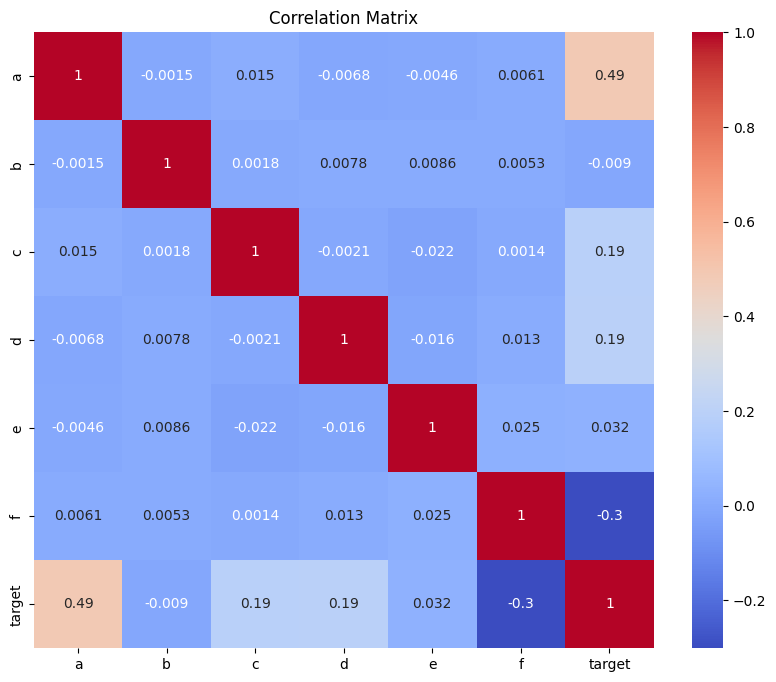

In [3]:
print(train.describe())
print("\nMissing Values:\n", train.isnull().sum())

plt.figure(figsize=(10,8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# FEATURE ENGINEERING


In [4]:
features = ['a','b','c','d','e','f']

# Fill missing values
train.fillna(train.median(numeric_only=True), inplace=True)
test.fillna(test.median(numeric_only=True), inplace=True)

# Polynomial Features (Degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_train = poly.fit_transform(train[features])
poly_test = poly.transform(test[features])

# Scaling
scaler = StandardScaler()
train_scaled = scaler.fit_transform(poly_train)
test_scaled = scaler.transform(poly_test)

y = train['target']

# CROSS VALIDATION SETUP


In [5]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# MODEL TRAINING + BLENDING



In [6]:
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test_scaled))

for fold, (train_idx, val_idx) in enumerate(kf.split(train_scaled)):

    X_train, X_val = train_scaled[train_idx], train_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Models
    xgb = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED
    )

    lgb = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        random_state=SEED
    )

    cat = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=SEED
    )

    xgb.fit(X_train, y_train)
    lgb.fit(X_train, y_train)
    cat.fit(X_train, y_train)

    val_pred = (
        0.33 * xgb.predict(X_val) +
        0.33 * lgb.predict(X_val) +
        0.34 * cat.predict(X_val)
    )

    oof_preds[val_idx] = val_pred

    test_preds += (
        0.33 * xgb.predict(test_scaled) +
        0.33 * lgb.predict(test_scaled) +
        0.34 * cat.predict(test_scaled)
    ) / kf.n_splits

    print(f"Fold {fold+1} RMSE:", rmse(y_val, val_pred))

print("Final CV RMSE:", rmse(y, oof_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6575
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 27
[LightGBM] [Info] Start training from score 29.491462
Fold 1 RMSE: 5.402108202042968
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6575
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 27
[LightGBM] [Info] Start training from score 29.379140
Fold 2 RMSE: 5.216642352749091
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6575
[LightGBM] [Info] Number of data points in the train set: 

# CREATE SUBMISSION FILE

In [7]:
submission = pd.DataFrame({
    "id": test["id"],
    "target": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,target
0,ID_6252,63.355856
1,ID_4684,25.142631
2,ID_1731,-6.816100
3,ID_4742,32.071437
4,ID_4521,36.414933
